In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/thesis/processed/

combined_pixels.csv	  landslide_points_sampled2.csv
FR_results_features1.csv  landslide_points_sampled.csv
FR_results_features.csv


In [ ]:
pixels_df = pd.read_csv('/content/drive/MyDrive/thesis/processed/combined_pixels.csv')
lands_df = pd.read_csv('/content/drive/MyDrive/thesis/processed/landslide_points_sampled2.csv',
                       low_memory=False, encoding='latin')

In [ ]:
col_to_factor = {
    'slope_class1': 'slope',
    'aspect_class1': 'utm_Aspect',
    'elevation_class1': 'elevation',
    'plan_curvature_class1': 'plan_curv',
    'profile_curvature_class1': 'profile_curv',
    'twi_class1': 'twi',
    'tri_class1': 'tri',
    'ndvi_class1': 'ndvi',
    'lulc_class1': 'utm_lulc',
    'proximity_roads_class1': 'proximity_roads',
    'proximity_rivers_class1': 'proximity_rivers',
    'proximity_fault_class1': 'proximity_fault',
    'max_rainfall_class1': 'max_rainfall',
    'mean_monsoon_class1': 'monsoon_rainfall',
    'mean_rainfall_class1': 'mean_rainfall',
    'log_flow_accumulation1': 'flow_accumulation',
}

In [ ]:
threshold_class = 2   # (removes 0–10° class)

Filter landslide data

In [ ]:
lands_df = lands_df[
    lands_df['slope_class1'] >= threshold_class
]

Filter pixel counts (this fixes denominator bias)

In [ ]:
pixels_df = pixels_df[
    ~(
        (pixels_df['factor'] == 'slope') &
        (pixels_df['class'] < threshold_class)
    )
]

Recompute totals AFTER masking

In [ ]:
N = len(lands_df)

S = pixels_df[pixels_df['factor'] == 'slope']['Npix_i'].sum()

print(f"Masked landslides (N): {N}")
print(f"Masked pixels (S): {S}")

Masked landslides (N): 15856
Masked pixels (S): 44783653


FR computation

In [ ]:
all_results = []

for col, factor in col_to_factor.items():

    # Landslide count per class
    ni = (lands_df[col]
          .value_counts()
          .rename_axis('class')
          .reset_index(name='Nls_i'))
    ni['class'] = ni['class'].astype(float)

    # Pixel count per class
    si = pixels_df[pixels_df['factor'] == factor][['class', 'Npix_i']].copy()
    si['class'] = si['class'].astype(float)

    # Merge
    merged = si.merge(ni, on='class', how='left')
    merged['Nls_i'] = merged['Nls_i'].fillna(0)

    # FR formula
    merged['factor'] = factor
    merged['N'] = N
    merged['S'] = S
    merged['FR'] = (merged['Nls_i'] / N) / (merged['Npix_i'] / S)

    merged['FR'] = merged['FR'].replace([np.inf, -np.inf], 0)

    all_results.append(merged)

Combine + log weights`

In [ ]:
fr_df = pd.concat(all_results, ignore_index=True)

fr_df = fr_df[['factor', 'class', 'Npix_i', 'Nls_i', 'N', 'S', 'FR']]
fr_df = fr_df.sort_values(['factor', 'class']).reset_index(drop=True)

fr_df['FR'] = fr_df['FR'].replace(0, 0.01)
fr_df['FR'] = fr_df['FR'].clip(lower=0.01, upper=5)

# log(FR)
fr_df['weight'] = np.log(fr_df['FR'].clip(lower=0.01))

In [ ]:
output_path = '/content/drive/MyDrive/thesis/processed/FR_results_features_masked.csv'

fr_df.to_csv(output_path, index=False)

print(f"\n Saved: {output_path}")


 Saved: /content/drive/MyDrive/thesis/processed/FR_results_features_masked.csv


In [ ]:
path = '/content/drive/MyDrive/thesis/processed/FR_results_features_masked.csv'
fr_df=pd.read_csv(path, encoding='latin')

In [ ]:
for factor in fr_df['factor'].unique():
    sub = fr_df[fr_df['factor'] == factor][['class', 'FR']]
    print(f"\n--- {factor} ---")
    print(sub.to_string(index=False))


--- elevation ---
 class       FR
   1.0 2.613391
   2.0 0.388679
   3.0 0.010000
   4.0 0.010000

--- flow_accumulation ---
 class       FR
   1.0 0.489150
   2.0 0.895414
   3.0 0.943560
   4.0 0.676864

--- max_rainfall ---
 class       FR
   1.0 0.032710
   2.0 0.879078
   3.0 0.589981
   4.0 0.854040

--- mean_rainfall ---
 class       FR
   1.0 0.214365
   2.0 0.894211
   3.0 0.640673
   4.0 0.979001

--- monsoon_rainfall ---
 class       FR
   1.0 0.025230
   2.0 0.909402
   3.0 0.616503
   4.0 0.928879

--- ndvi ---
 class       FR
   1.0 0.010000
   2.0 0.368305

--- plan_curv ---
 class       FR
   1.0 0.010000
   2.0 0.010000
   3.0 3.492766
   4.0 0.010000
   5.0 0.010000

--- profile_curv ---
 class      FR
   1.0 0.01000
   2.0 0.02858
   3.0 3.73500
   4.0 0.01000
   5.0 0.01000

--- proximity_fault ---
 class       FR
   1.0 0.865388
   2.0 0.618040
   3.0 0.988218
   4.0 0.405740

--- proximity_rivers ---
 class       FR
   1.0 1.927749
   2.0 0.539539
   3.0 0.332660

In [ ]:
fr_df[fr_df['FR'] == 0]

,factor,class,Npix_i,Nls_i,N,S,FR,weight


In [ ]:


print("Factors:", fr_df['factor'].unique())

# Check slope classes
print("\nSlope classes:")
print(fr_df[fr_df['factor'] == 'slope'][['class', 'FR']])

# Check extreme values
print("\nMax FR:", fr_df['FR'].max())
print("Min FR:", fr_df['FR'].min())

# Check zeros
print("\nZero FR rows:", len(fr_df[fr_df['FR'] == 0]))

# Check distribution
print("\nTop 10 highest FR:")
print(fr_df.sort_values('FR', ascending=False).head(10))

Factors: ['elevation' 'flow_accumulation' 'max_rainfall' 'mean_rainfall'
 'monsoon_rainfall' 'ndvi' 'plan_curv' 'profile_curv' 'proximity_fault'
 'proximity_rivers' 'proximity_roads' 'slope' 'tri' 'twi' 'utm_Aspect'
 'utm_lulc']

Slope classes:
    class        FR
44    2.0  0.208988
45    3.0  1.677859
46    4.0  1.094537

Max FR: 5.0
Min FR: 0.01

Zero FR rows: 0

Top 10 highest FR:
              factor  class    Npix_i    Nls_i      N         S        FR  \
64          utm_lulc   20.0    110224    890.0  15856  44783653  5.000000   
67          utm_lulc   50.0    688658    927.0  15856  44783653  3.801912   
29      profile_curv    3.0  11896500  15732.0  15856  44783653  3.735000   
24         plan_curv    3.0  12802424  15832.0  15856  44783653  3.492766   
40   proximity_roads    1.0  14830374  14685.0  15856  44783653  2.796712   
0          elevation    1.0  14907734  13794.0  15856  44783653  2.613391   
36  proximity_rivers    1.0  14878370  10155.0  15856  44783653  1.927749

In [ ]:
# Group by factor
fr_importance = (
    fr_df.groupby('factor')['FR']
    .mean()
    .reset_index()
)

In [ ]:
total_fr = fr_importance['FR'].sum()

fr_importance['Contribution (%)'] = (
    fr_importance['FR'] / total_fr
) * 100

In [ ]:
# Sort descending
fr_importance = fr_importance.sort_values(
    'Contribution (%)',
    ascending=False
)

print(fr_importance)

               factor        FR  Contribution (%)
15           utm_lulc  1.199171         11.089673
11              slope  0.993794          9.190398
7        profile_curv  0.758716          7.016443
0           elevation  0.755518          6.986864
1   flow_accumulation  0.751247          6.947369
10    proximity_roads  0.750781          6.943063
9    proximity_rivers  0.744639          6.886263
8     proximity_fault  0.719346          6.652362
6           plan_curv  0.706553          6.534052
3       mean_rainfall  0.682062          6.307567
13                twi  0.675201          6.244118
14         utm_Aspect  0.668262          6.179940
4    monsoon_rainfall  0.620004          5.733660
2        max_rainfall  0.588953          5.446507
5                ndvi  0.189153          1.749244
12                tri  0.010000          0.092478


In [ ]:
rename_dict = {
    'utm_lulc': 'LULC',
    'utm_Aspect': 'Aspect',
    'profile_curv': 'Profile Curvature',
    'plan_curv': 'Plan Curvature',
    'elevation': 'Elevation',
    'flow_accumulation': 'Flow Accumulation',
    'proximity_roads': 'Proximity to Roads',
    'slope': 'Slope',
    'proximity_rivers': 'Proximity to Rivers',
    'proximity_fault': 'Proximity to Faults',
    'mean_rainfall': 'Mean Rainfall',
    'twi': 'TWI',
    'monsoon_rainfall': 'Monsoon Rainfall',
    'max_rainfall': 'Maximum Rainfall',
    'ndvi': 'NDVI',
    'tri': 'TRI'
}

fr_importance['factor'] = fr_importance['factor'].replace(rename_dict)

In [ ]:
import matplotlib.pyplot as plt

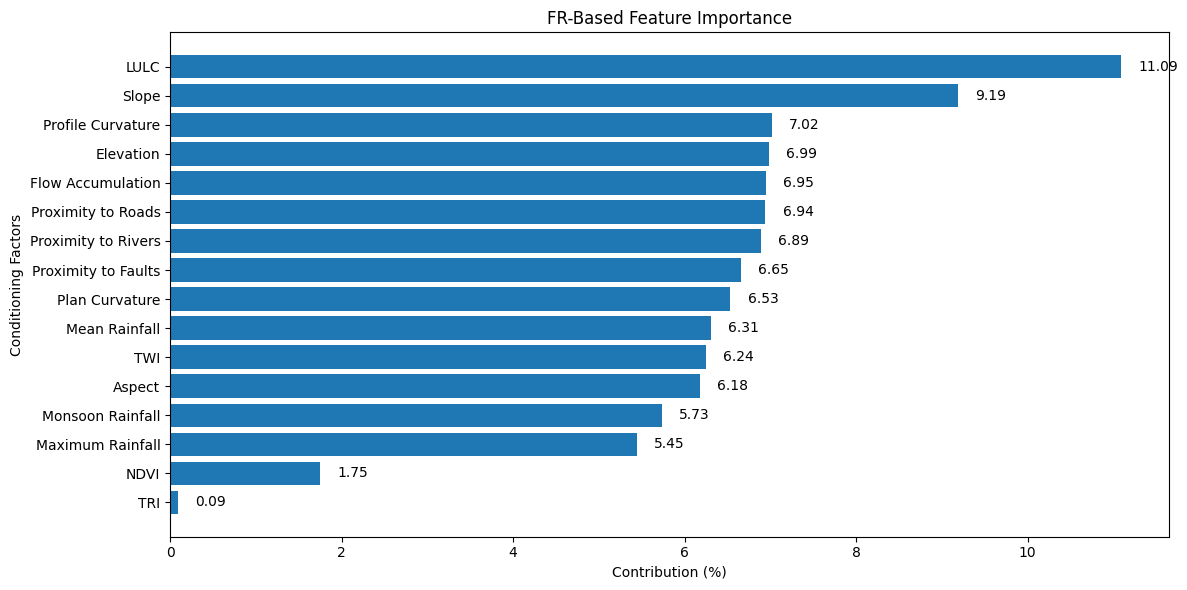

In [ ]:
plt.figure(figsize=(12,6))

plt.barh(
    fr_importance['factor'],
    fr_importance['Contribution (%)']
)
plt.xlabel('Contribution (%)')
plt.ylabel('Conditioning Factors')
plt.title('FR-Based Feature Importance')

for i, v in enumerate(fr_importance['Contribution (%)']):
    plt.text(v + 0.2,   # x position
        i,         # y position
        f"{v:.2f}",
        va='center')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()